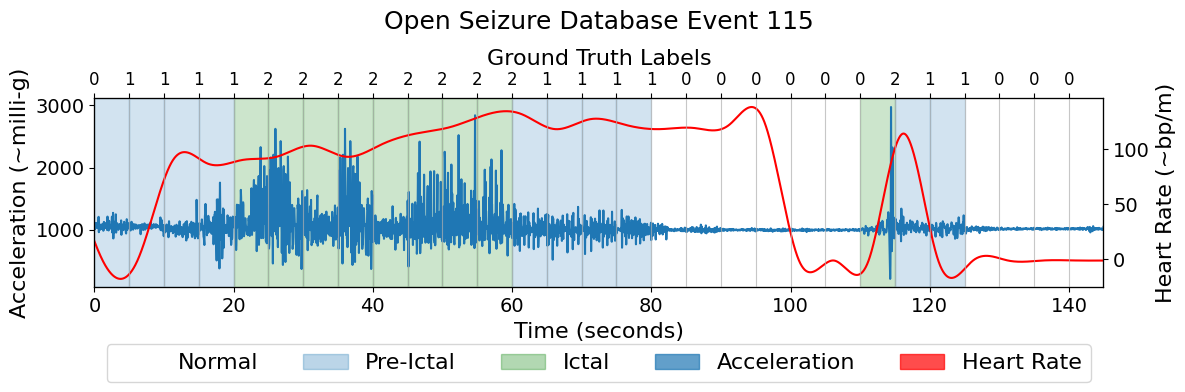

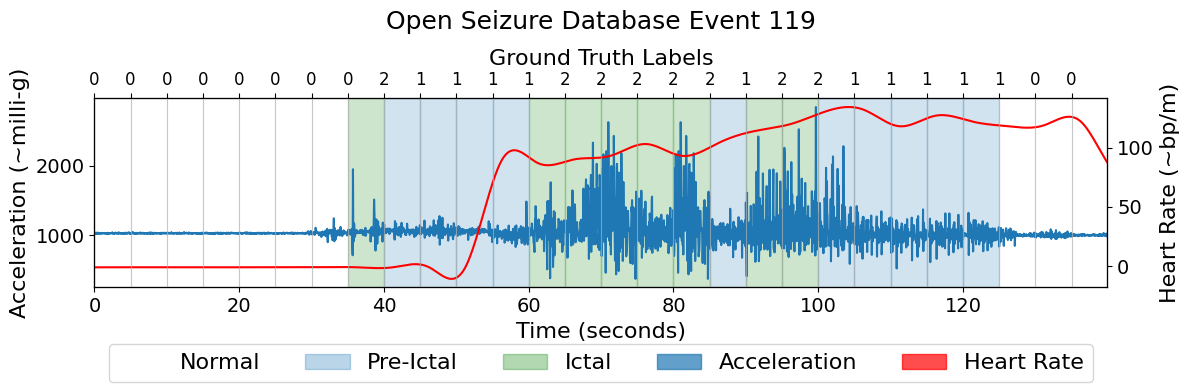

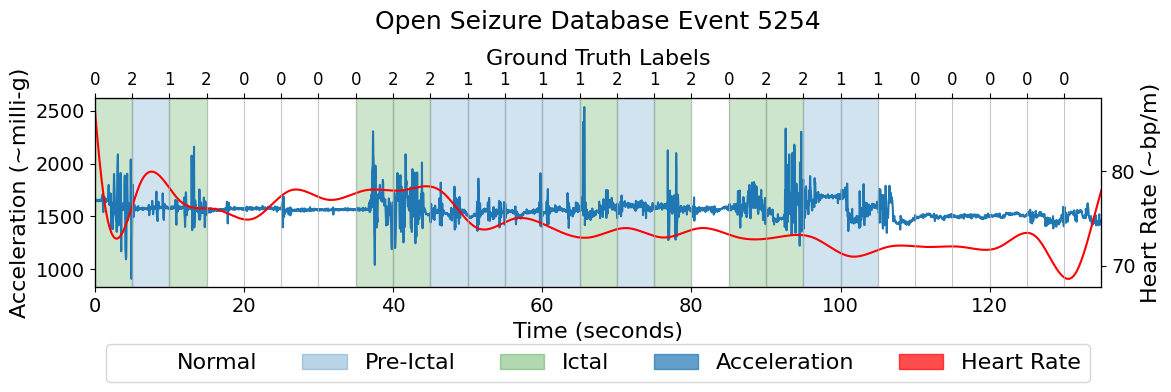

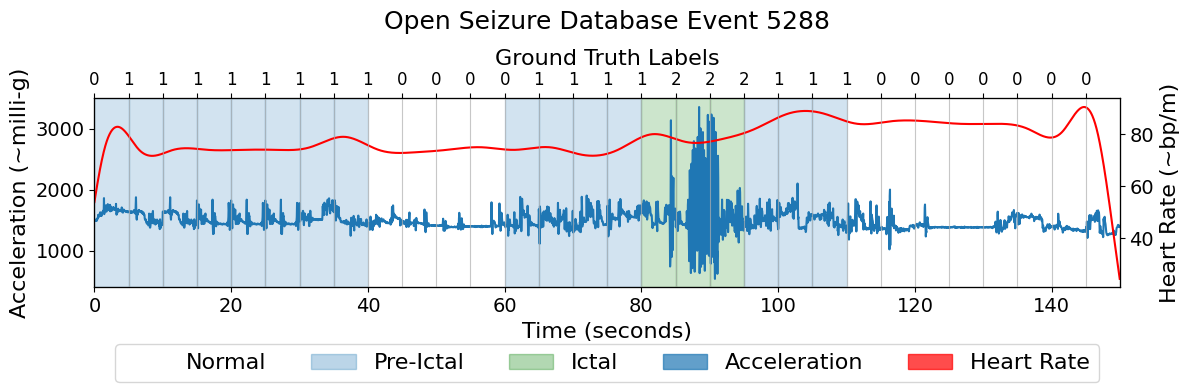

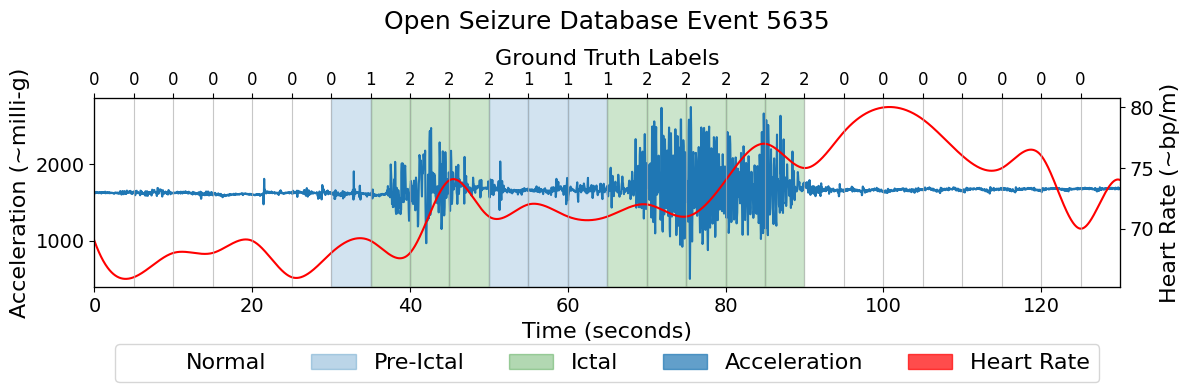

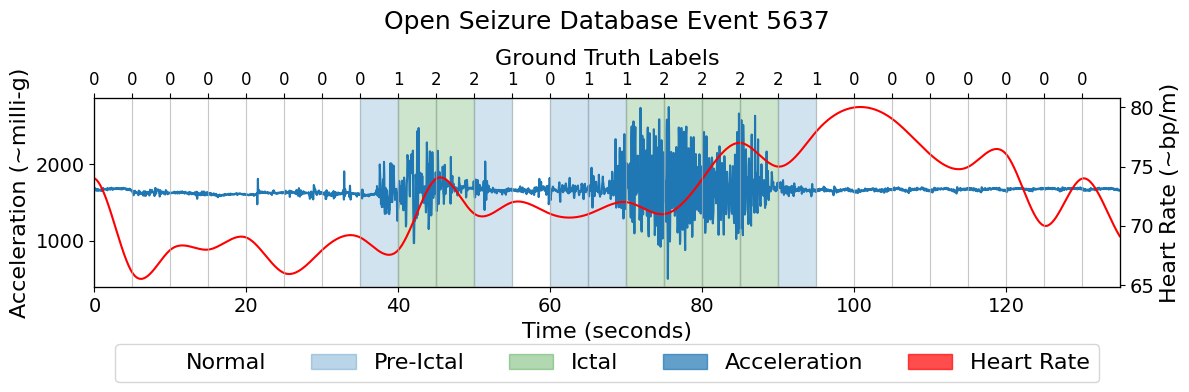

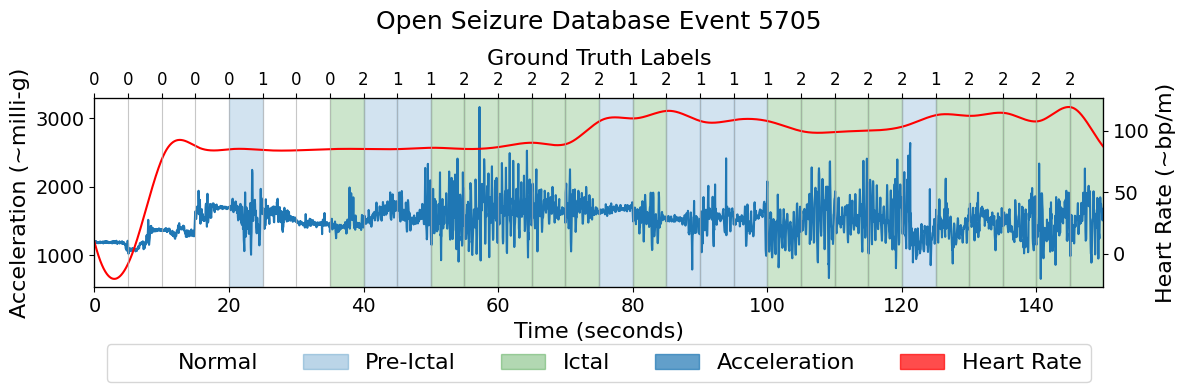

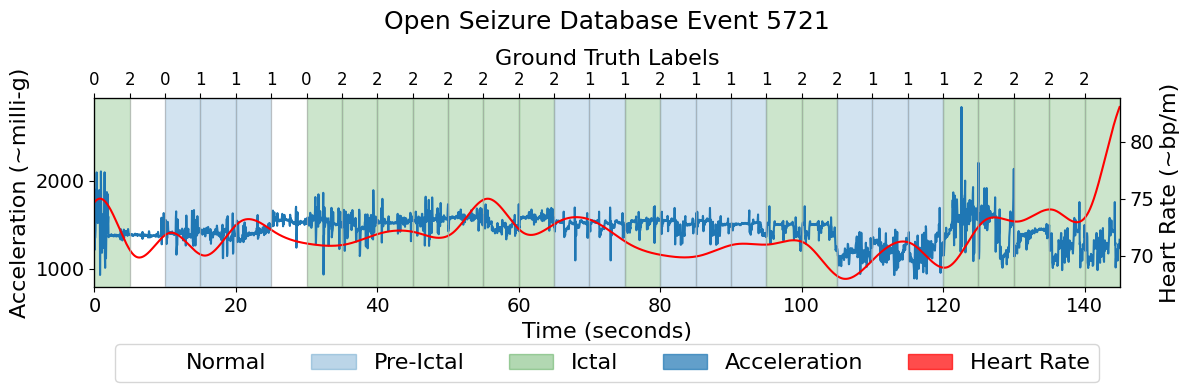

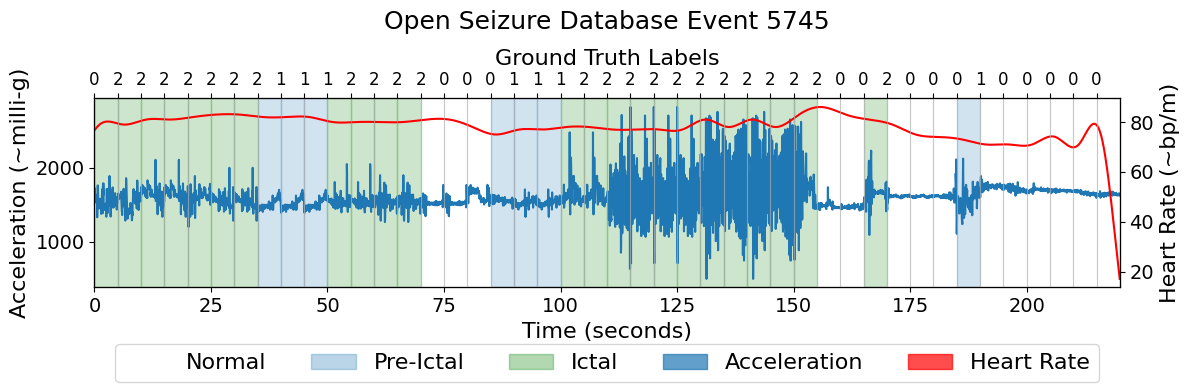

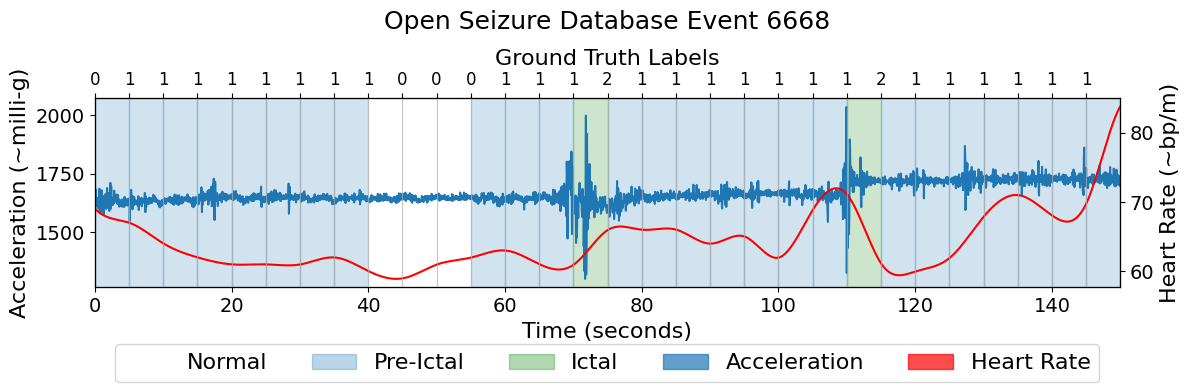

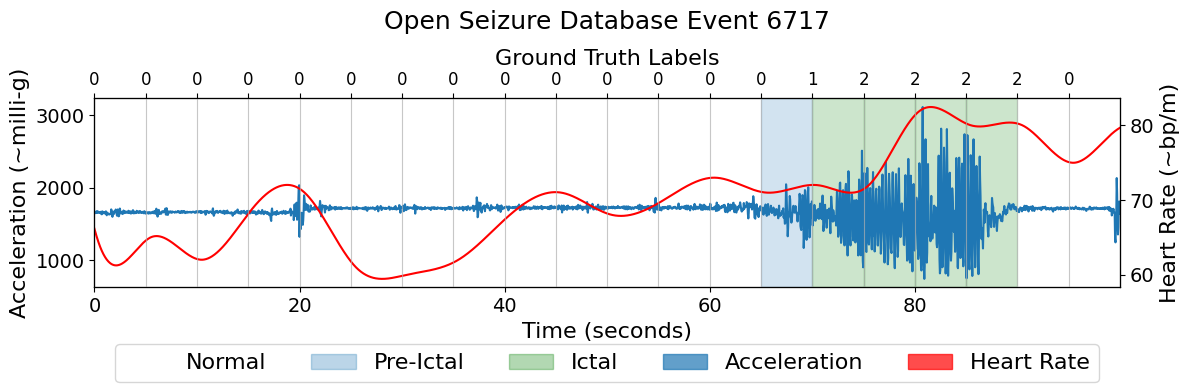

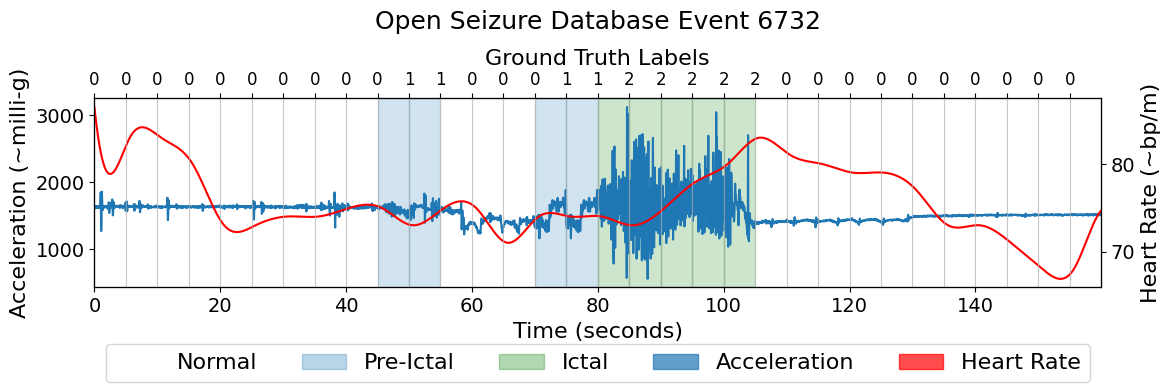

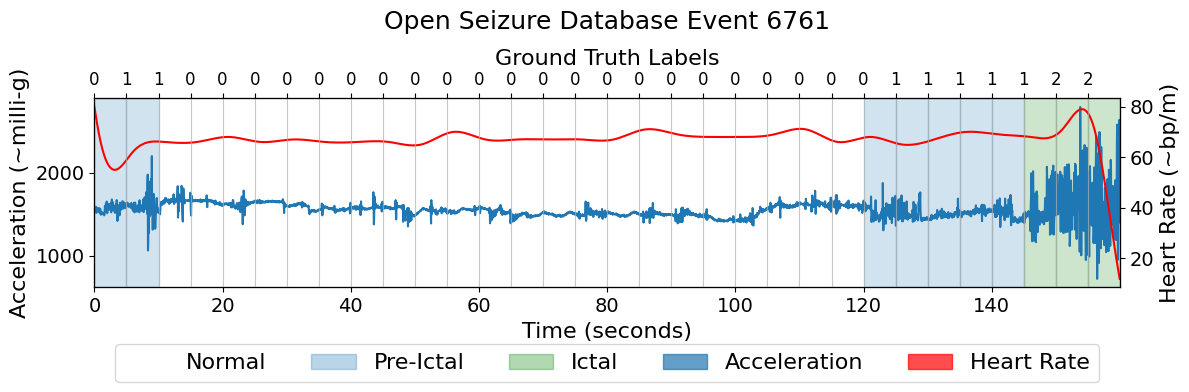

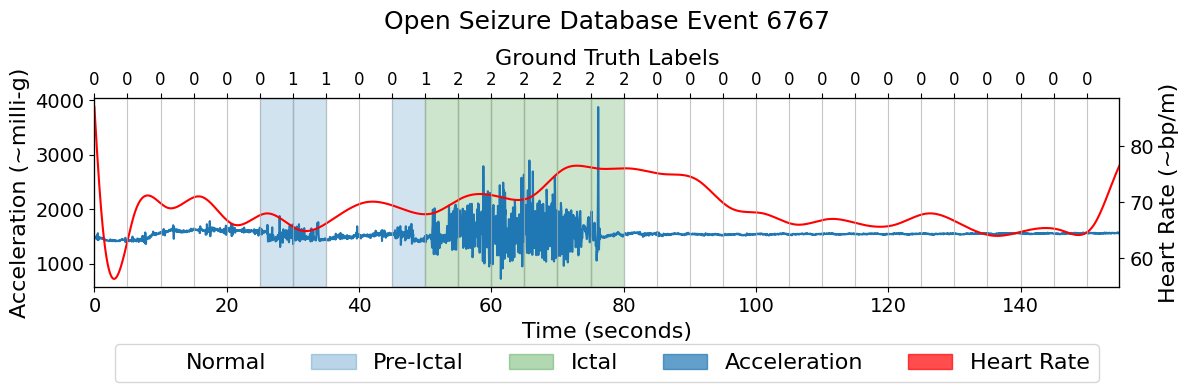

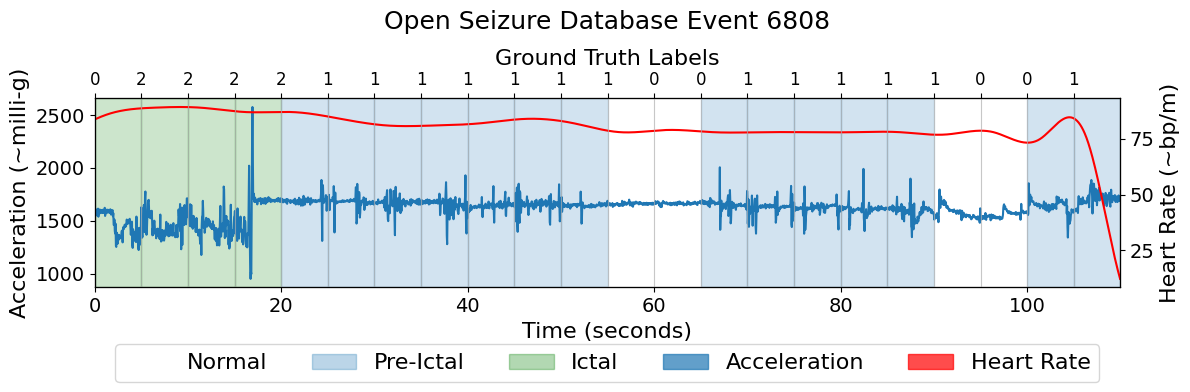

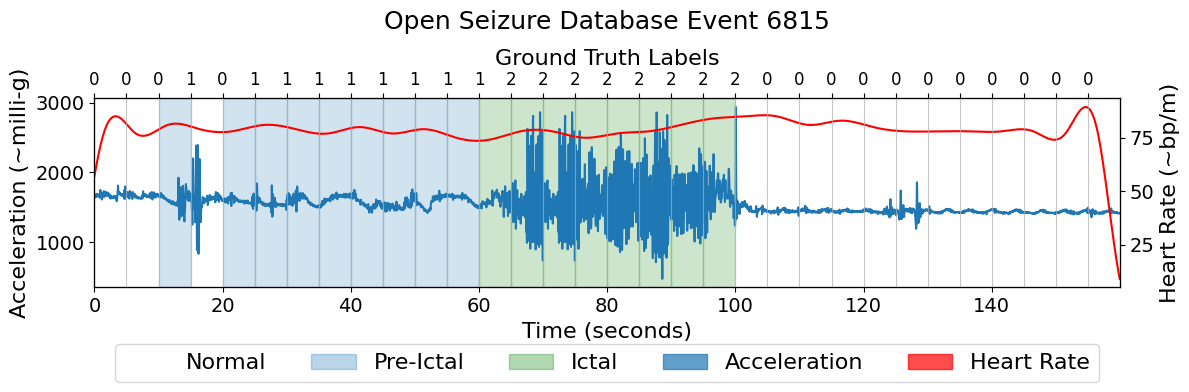

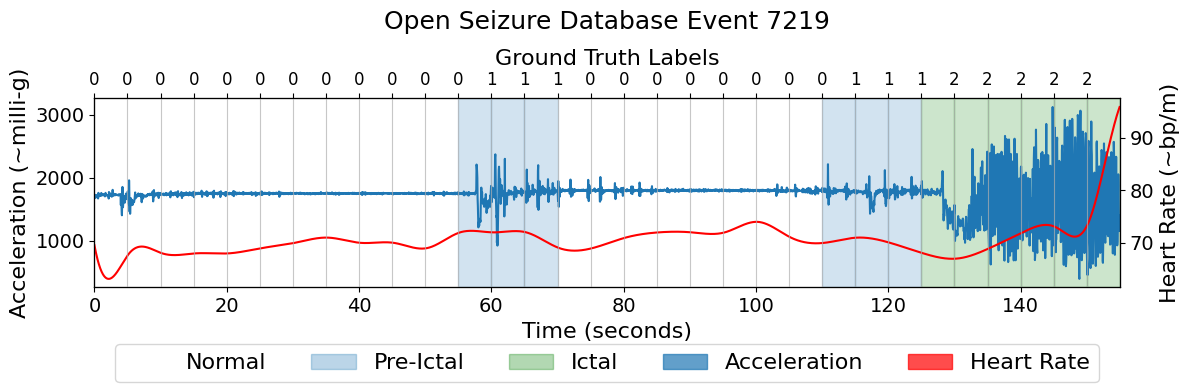

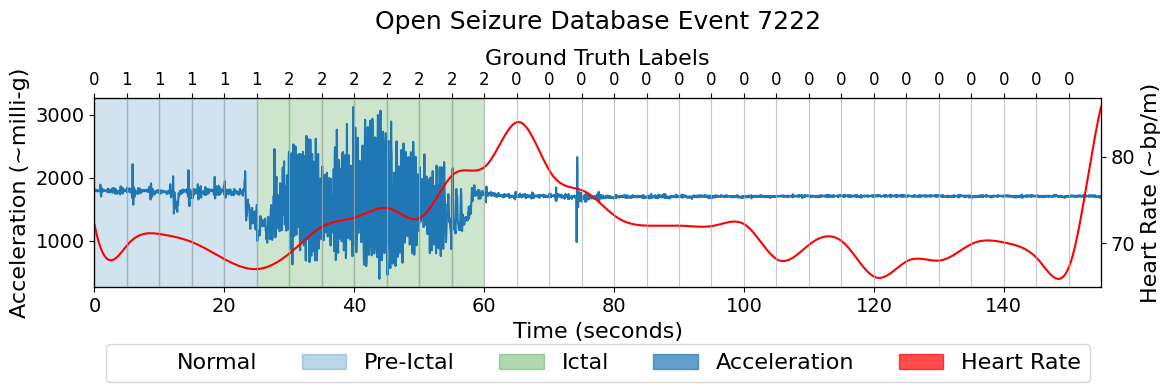

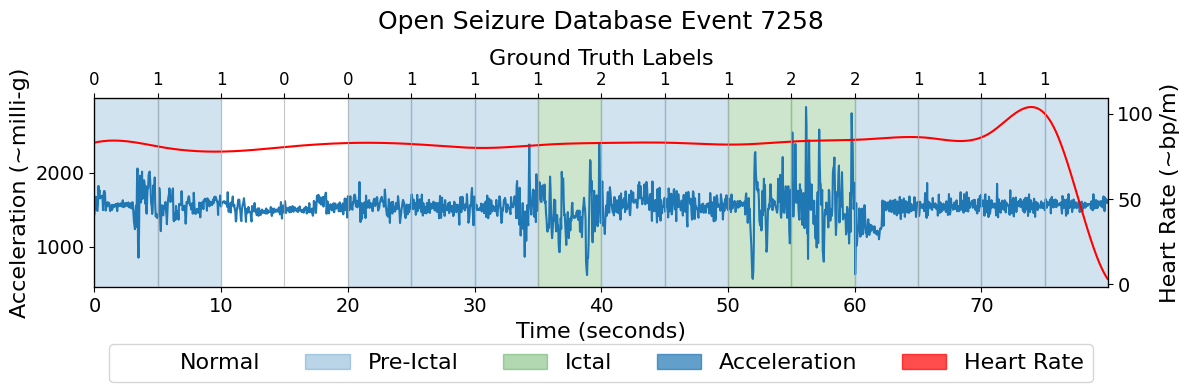

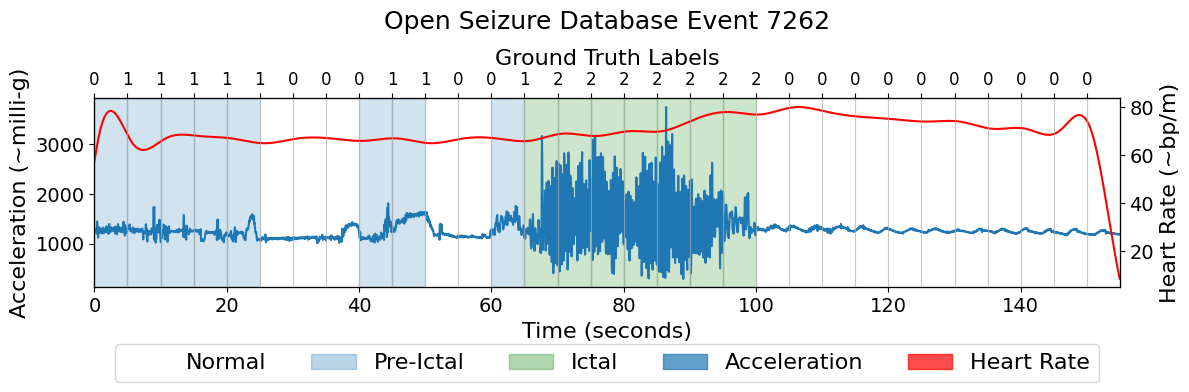

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
import os
import warnings

# Suppress specific warnings
warnings.filterwarnings("ignore", message=".*set_ticklabels.*")


# Reading data from Google Drive
sample_dataset_path = '../Data/sample_dataset.csv'
df = pd.read_csv(sample_dataset_path)

# Define colors for each class label
label_colors = {
    0: "white",     # Normal
    1: "tab:blue",  # Pre-Ictal
    2: "green"      # Ictal
}

# Create 'Events' folder if it doesn't exist
os.makedirs("Events", exist_ok=True)

# Plot each eventId
for event_id, event_data in df.groupby("eventId"):
    num_rows = event_data.shape[0]
    time_axis = np.arange(num_rows) / 25  # Assuming 25 samples per second
    time_steps = num_rows // 125  # Calculate timesteps
    
    # Extract unique labels for each timestep (every 125th row)
    labels = event_data["label"].iloc[::125].reset_index(drop=True)
    label_positions = [i * 5 for i in range(len(labels))]  # Position for each label (5 seconds per timestep)

    # Adding static 0 at the start of ax3's x-ticks to ensure alignment
    adjusted_label_positions = label_positions  # Start with static 0 for the first position
    adjusted_labels = [0] + labels.tolist()  # Add static 0 label for the first position

    fig, ax1 = plt.subplots(figsize=(12, 5))

    # Left Y-axis (Acceleration / rawData)
    ax1.plot(time_axis, event_data["rawData"], color="tab:blue", label="Acceleration (rawData)")  
    ax1.set_xlabel("Time (seconds)", fontsize=16)
    ax1.set_ylabel("Acceleration (~milli-g)", color="black", fontsize=16)
    ax1.tick_params(axis='y', labelcolor="black", labelsize=14)
    ax1.tick_params(axis='x', labelsize=14)

    # Right Y-axis (Heart Rate / ppg)
    ax2 = ax1.twinx()
    ax2.plot(time_axis, event_data["ppg"], color="red", label="Heart Rate (ppg)")  
    ax2.set_ylabel("Heart Rate (~bp/m)", fontsize=16)
    ax2.tick_params(axis='y', labelcolor="black", labelsize=14)

    # Add the labels on the upper x-axis (ax3) with a static 0 at the beginning
    ax3 = ax1.twiny()
    
    # Directly use the adjusted labels for ax3 ticks and labels
    ax3.set_xticklabels(adjusted_labels, fontsize=12)  # Use the adjusted labels directly
    ax3.set_xticks(adjusted_label_positions)  # Set the positions of the x-ticks
    ax3.set_xlabel("Ground Truth Labels", fontsize=16)
    ax3.tick_params(axis='x', labelsize=12)
    ax3.grid(axis='x', linestyle='-', linewidth=0.8, alpha=0.7)

    # Set the same xlim for ax1 and ax3
    ax1.set_xlim(0, time_axis[-1])
    ax3.set_xlim(0, time_axis[-1])

    # Add background colors for each class label based on label values (0, 1, 2)
    for i in range(len(labels)):
        start = label_positions[i]   # Shift background start by 5 seconds
        end = label_positions[i + 1] if i + 1 < len(labels) else time_axis[-1]  # Shift background end by 5 seconds
        color = label_colors.get(labels[i], "white")
        ax1.axvspan(start, end, color=color, alpha=0.2)  # Background color on ax1 (rawData)

    # Title with padding
    plt.title(f"Open Seizure Database Event {event_id}", fontsize=18, pad=50)

    # Add legends for background colors
    custom_legends = [
        mpatches.Patch(color="white", alpha=0.3, label="Normal"),
        mpatches.Patch(color="tab:blue", alpha=0.3, label="Pre-Ictal"),
        mpatches.Patch(color="green", alpha=0.3, label="Ictal"),
        mpatches.Patch(color="tab:blue", alpha=0.7, label="Acceleration"),
        mpatches.Patch(color="red", alpha=0.7, label="Heart Rate")
    ]
    
    ax1.legend(handles=custom_legends, loc='lower center', fontsize=16, frameon=True,
               ncol=5, bbox_to_anchor=(0.5, -0.5), borderaxespad=0)

    # Adjust layout for spacing
    fig.tight_layout()

    # Save the plot as a PNG image in the 'Events' folder
    plt.savefig(f"../Sample_Events/event_{event_id}.png")

    # Show the plot
    plt.show()


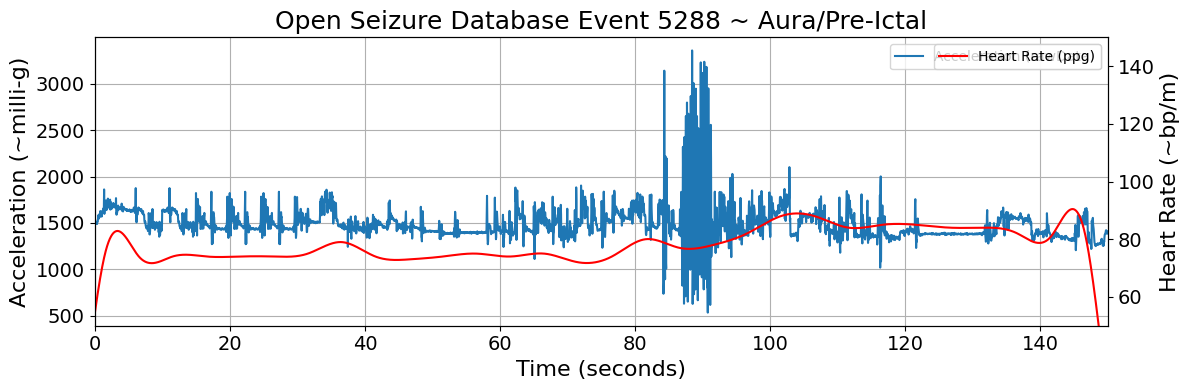

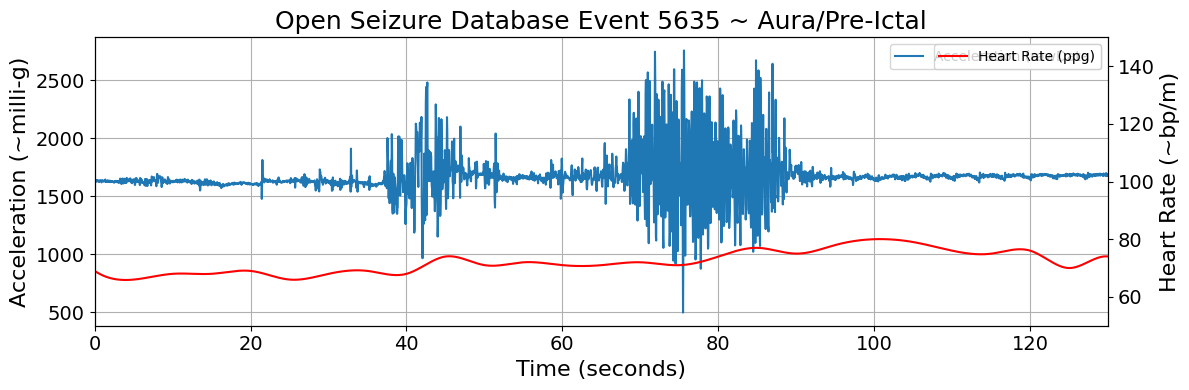

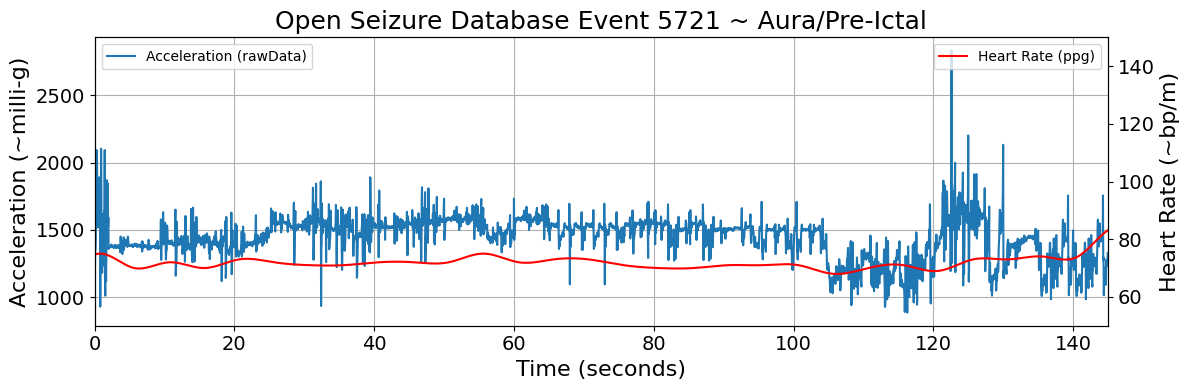

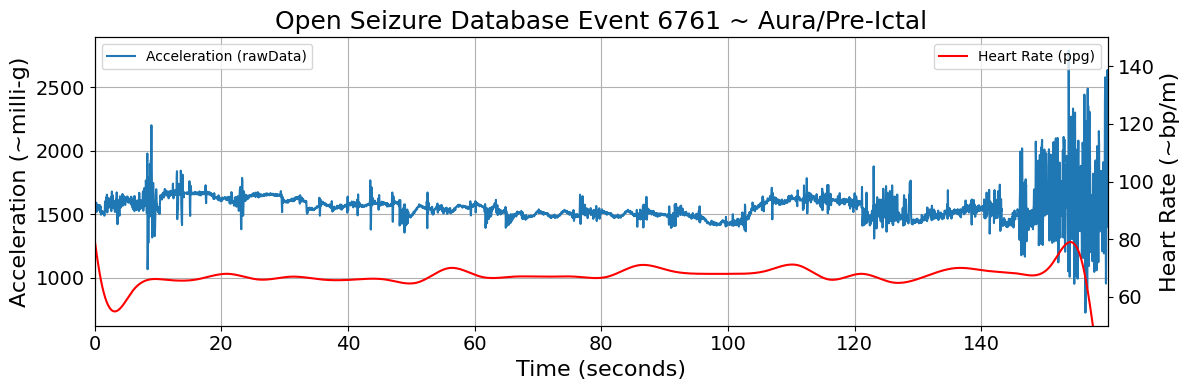

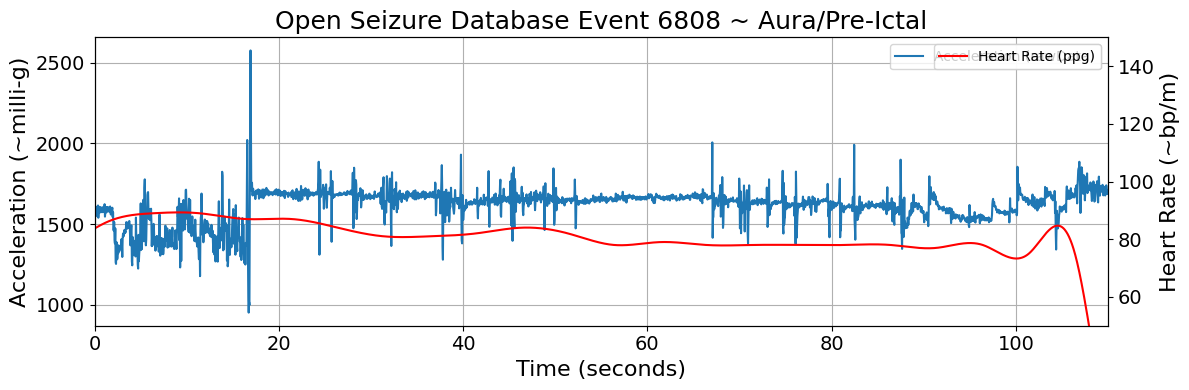

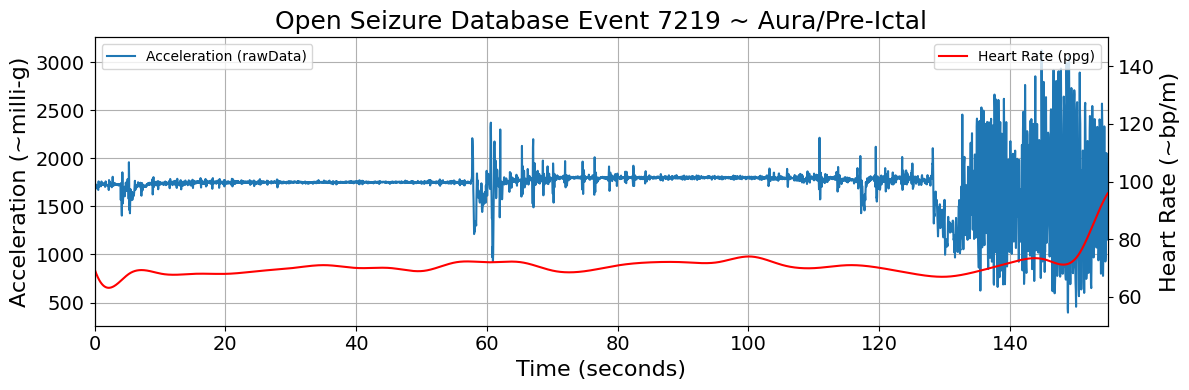

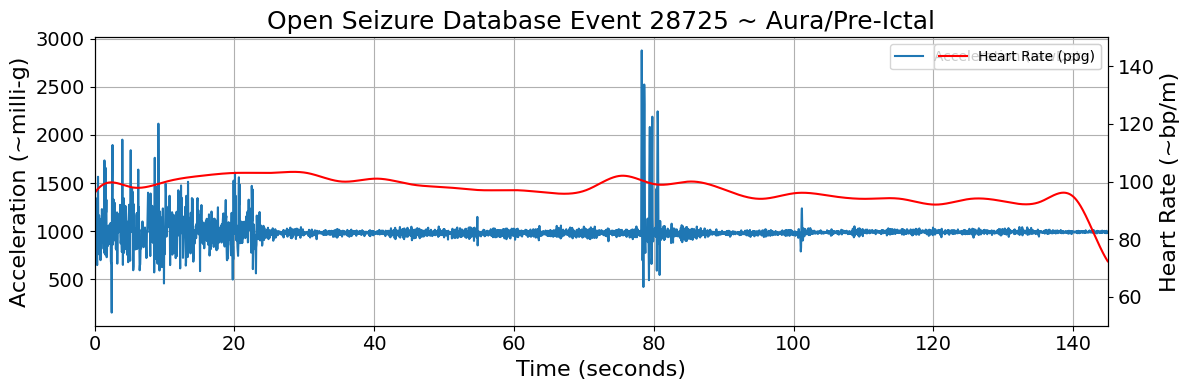

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
import os
import warnings

# Suppress specific warnings
warnings.filterwarnings("ignore", message=".*set_ticklabels.*")

# Reading data from Google Drive
sample_dataset_path = '../Data/sample_dataset.csv'
df = pd.read_csv(sample_dataset_path)
filtered_df = df[df['subType'] == 'Aura']


# Create 'Events' folder if it doesn't exist
os.makedirs("Events", exist_ok=True)

# Plot each eventId
for event_id, event_data in filtered_df.groupby("eventId"):
    num_rows = event_data.shape[0]
    time_axis = np.arange(num_rows) / 25  # Assuming 25 samples per second
    time_steps = num_rows // 125  # Calculate timesteps
    subType = event_data["subType"].unique
    # Extract unique labels for each timestep (every 125th row)
    labels = event_data["label"].iloc[::125].reset_index(drop=True)
    label_positions = [i * 5 for i in range(len(labels))]  # Position for each label (5 seconds per timestep)

    # Adding static 0 at the start of ax3's x-ticks to ensure alignment
    adjusted_label_positions = label_positions  # Start with static 0 for the first position
    adjusted_labels = [0] + labels.tolist()  # Add static 0 label for the first position

    fig, ax1 = plt.subplots(figsize=(12, 4))

    # Left Y-axis (Acceleration / rawData)
    ax1.plot(time_axis, event_data["rawData"], color="tab:blue", label="Acceleration (rawData)")  
    ax1.set_xlabel("Time (seconds)", fontsize=16)
    ax1.set_ylabel("Acceleration (~milli-g)", color="black", fontsize=16)
    ax1.tick_params(axis='y', labelcolor="black", labelsize=14)
    ax1.tick_params(axis='x', labelsize=14)

    # Right Y-axis (Heart Rate / ppg)
    ax2 = ax1.twinx()
    ax2.plot(time_axis, event_data["ppg"], color="red", label="Heart Rate (ppg)")  
    ax2.set_ylabel("Heart Rate (~bp/m)", fontsize=16)
    ax2.tick_params(axis='y', labelcolor="black", labelsize=14)

    # Set the same xlim for ax1 and ax3
    ax1.set_xlim(0, time_axis[-1])
    ax2.set_ylim(50,150)
    ax1.grid(True)
    ax1.legend()
    ax2.legend()

    # Title with padding
    plt.title(f"Open Seizure Database Event {event_id} ~ Aura/Pre-Ictal", fontsize=18)

    # Adjust layout for spacing
    fig.tight_layout()

     # Save the plot as a PNG image in the 'Events' folder
    plt.savefig(f"../Sample_Event_Types/Aura/event_{event_id}.png")

    # Show the plot
    plt.show()



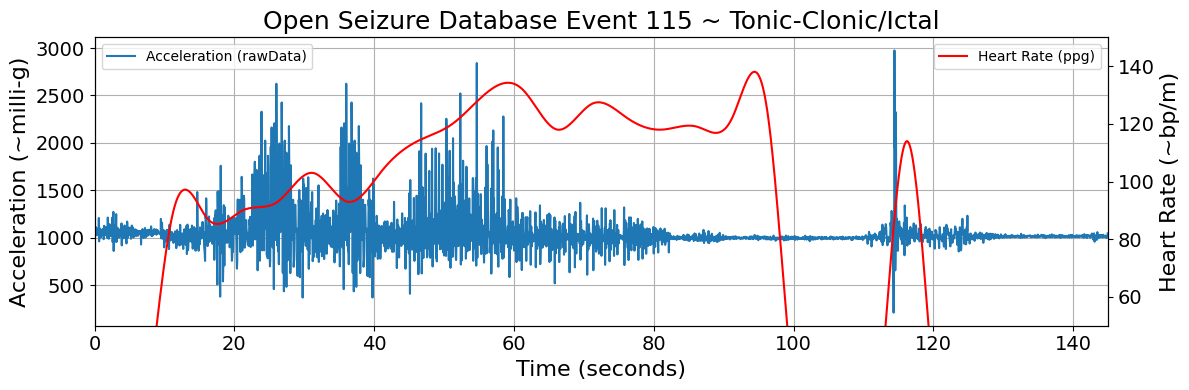

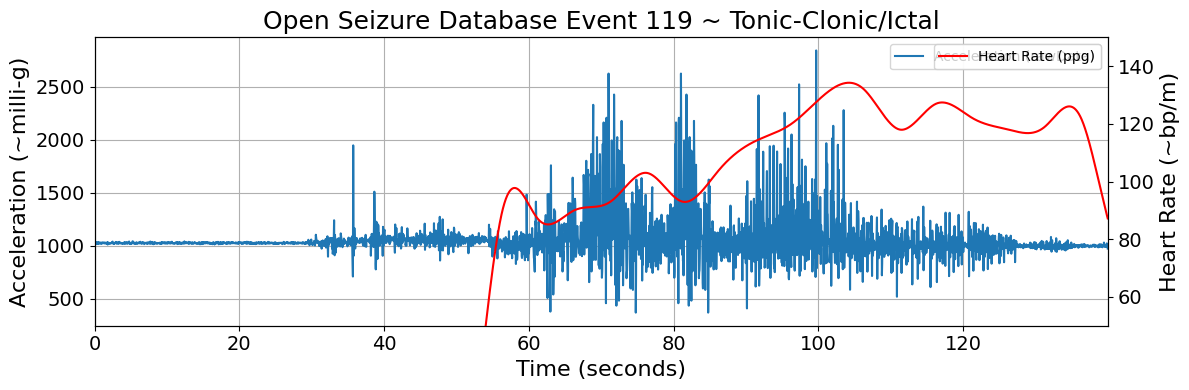

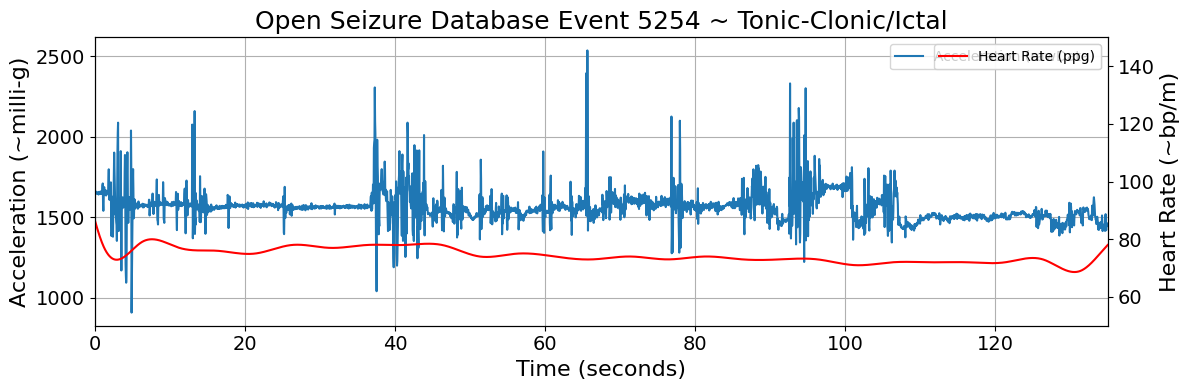

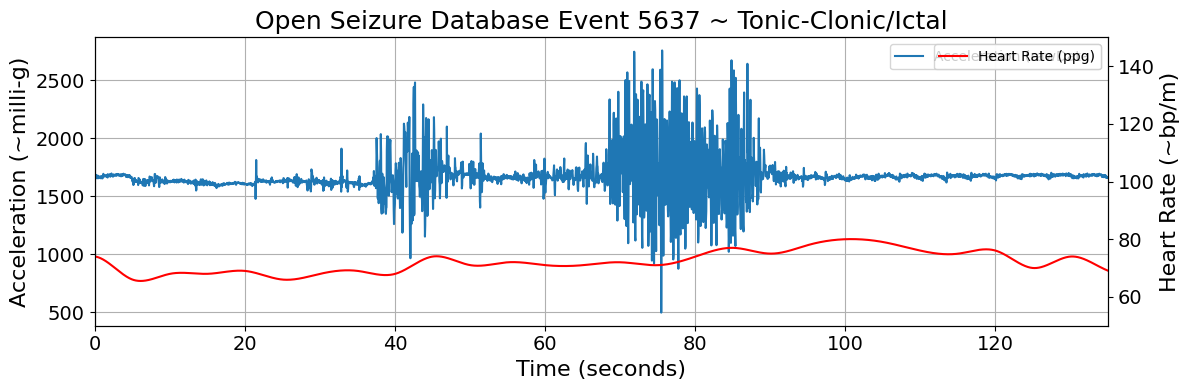

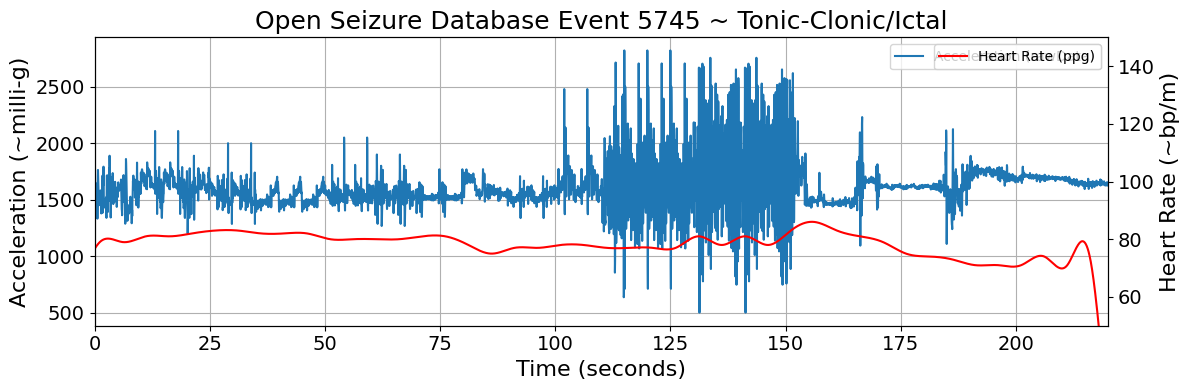

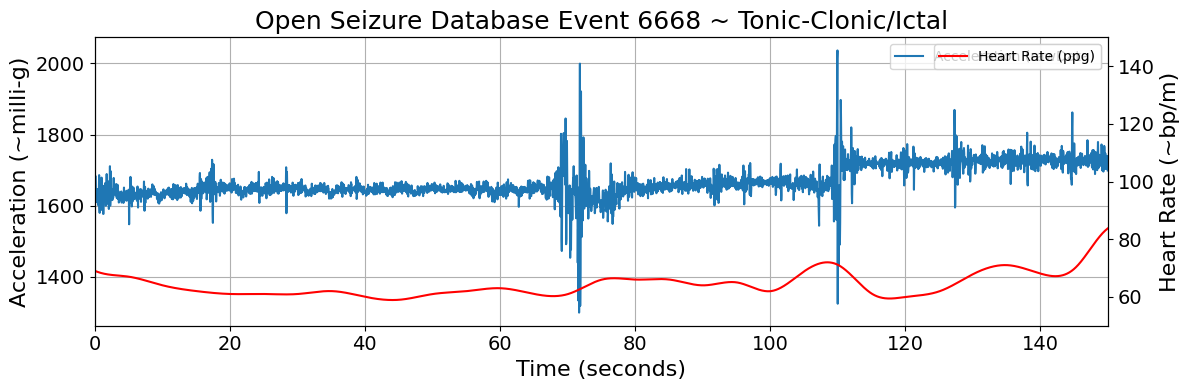

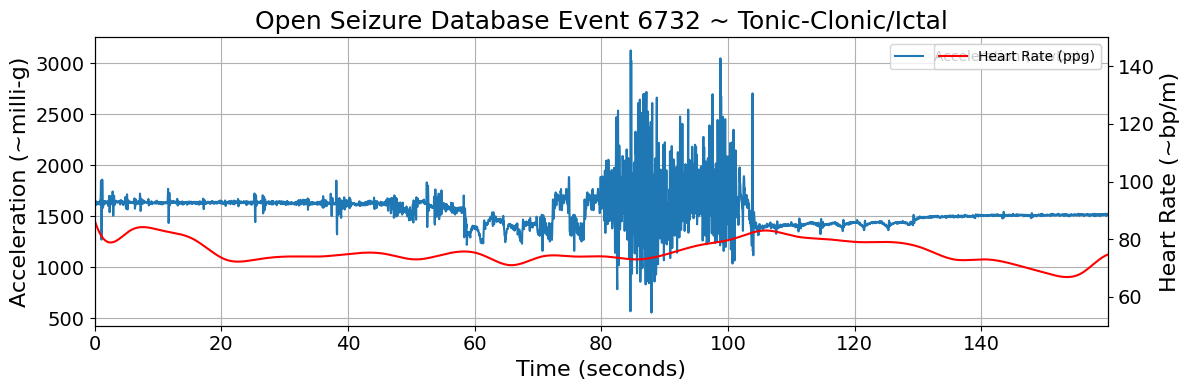

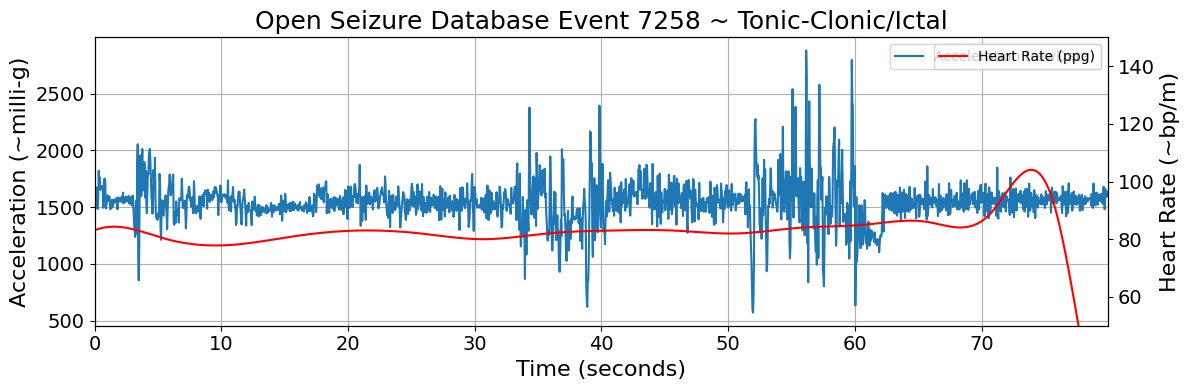

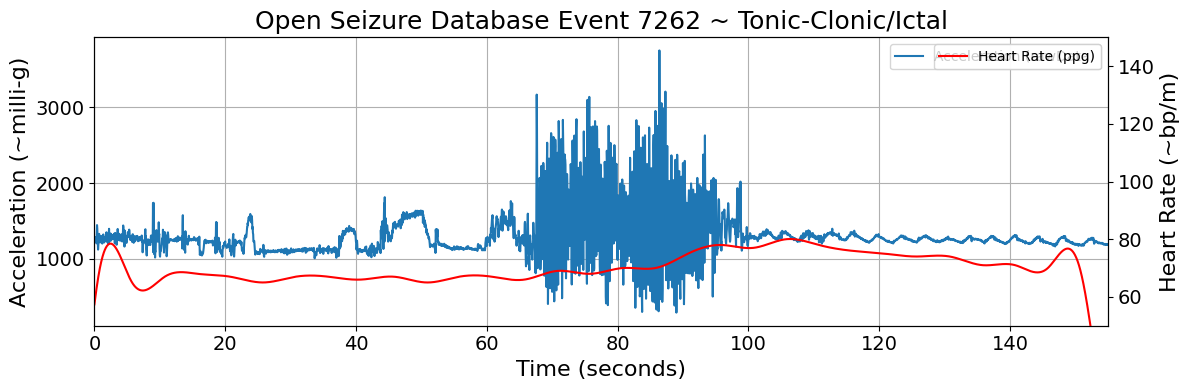

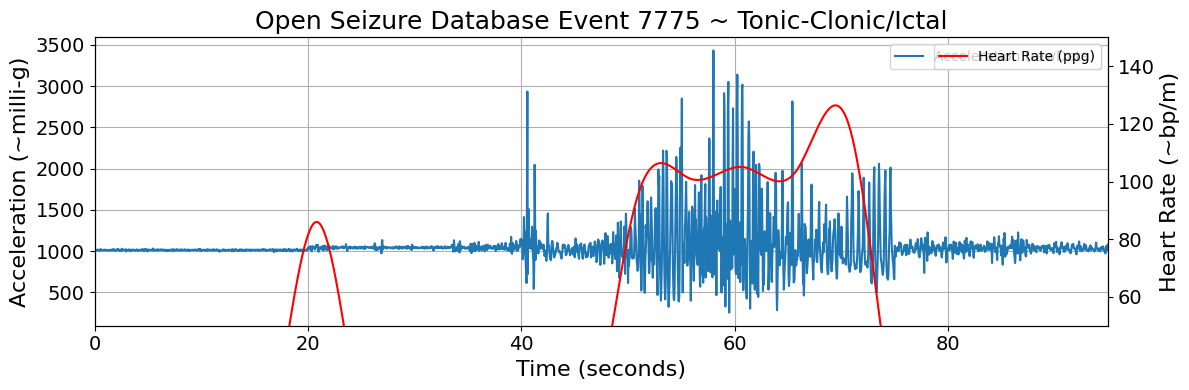

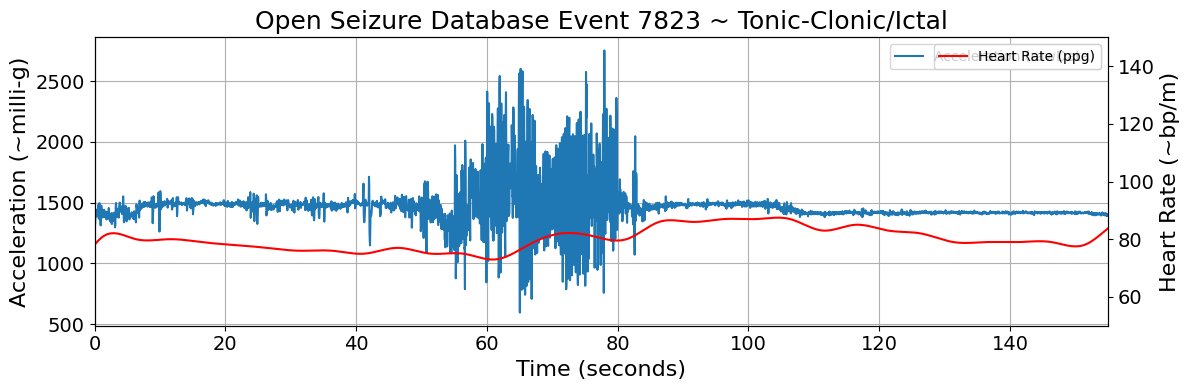

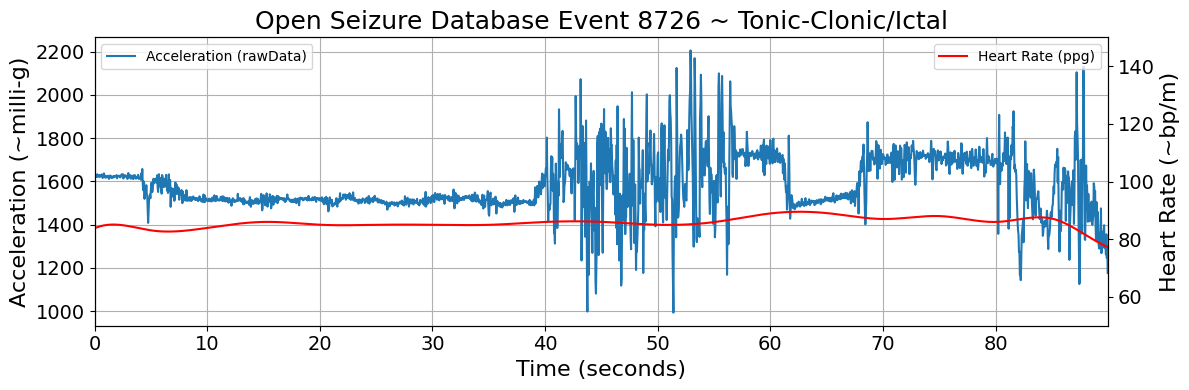

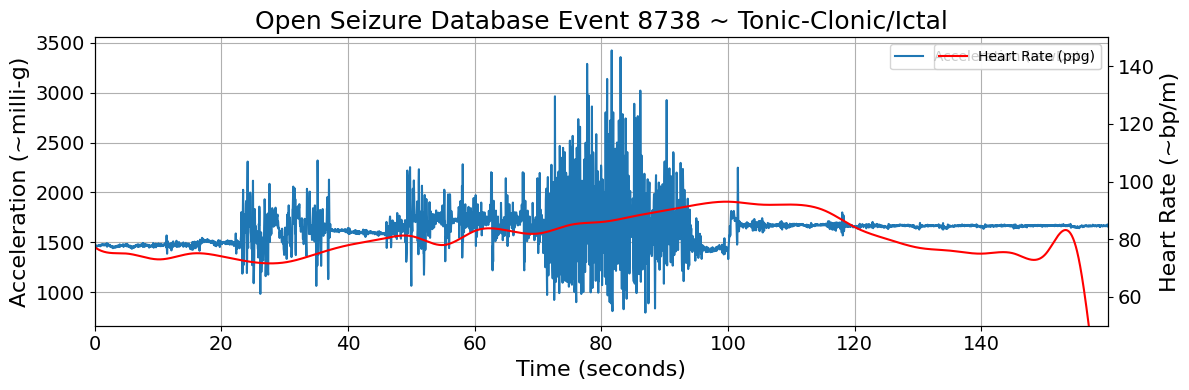

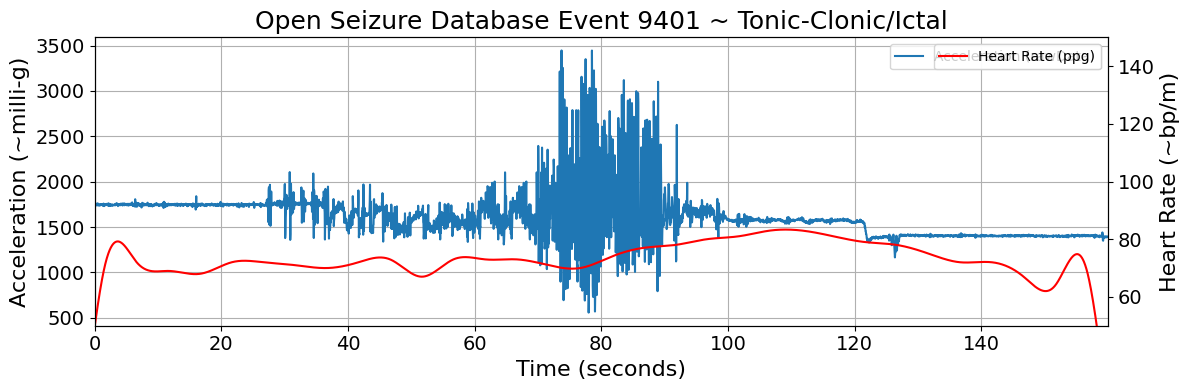

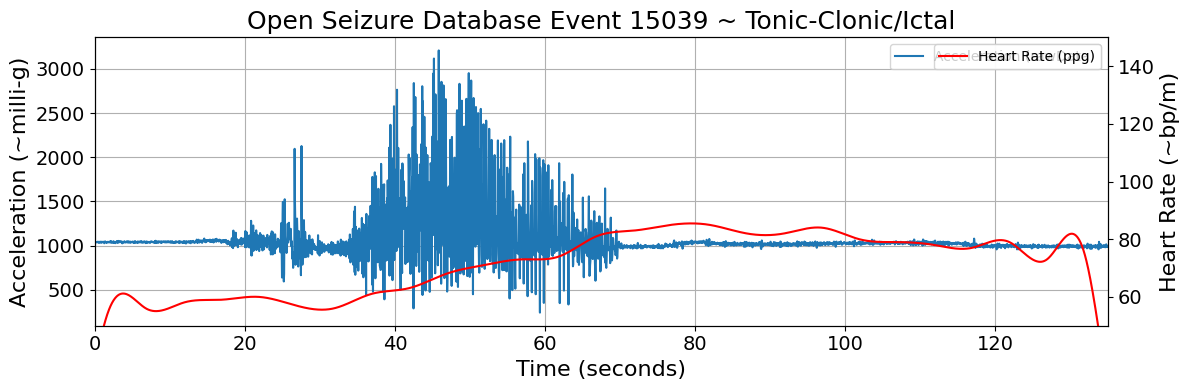

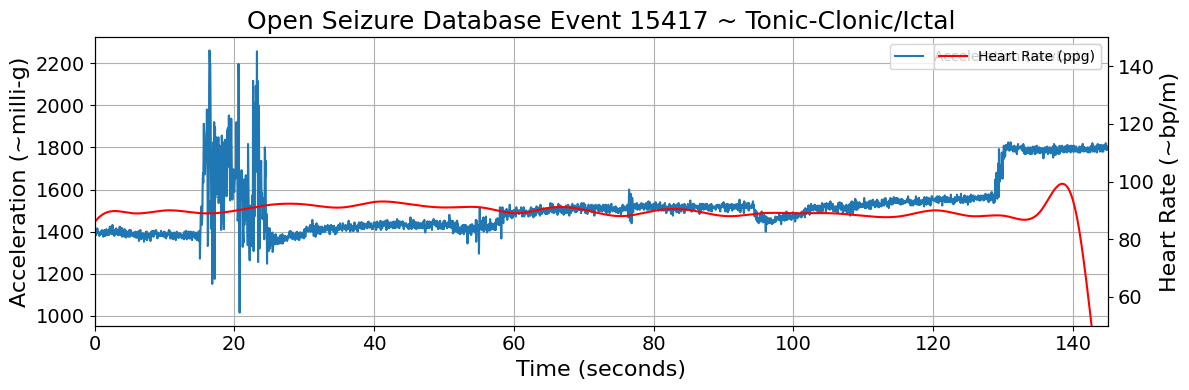

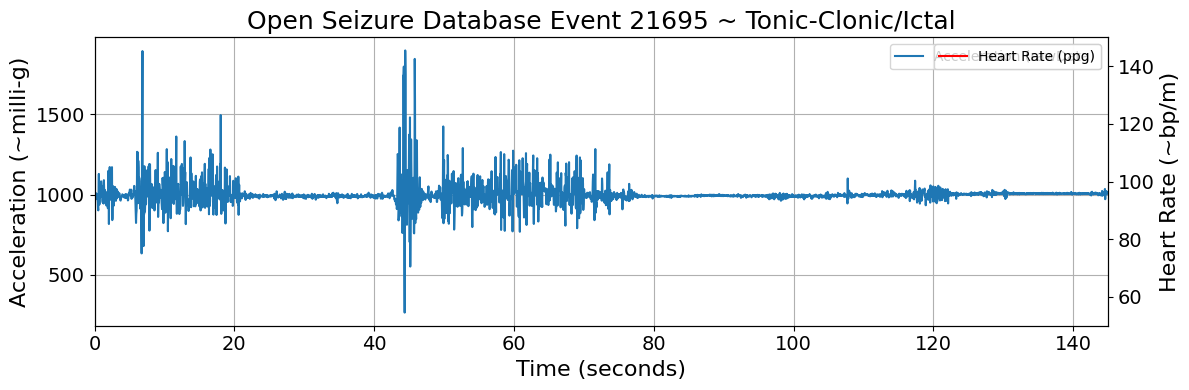

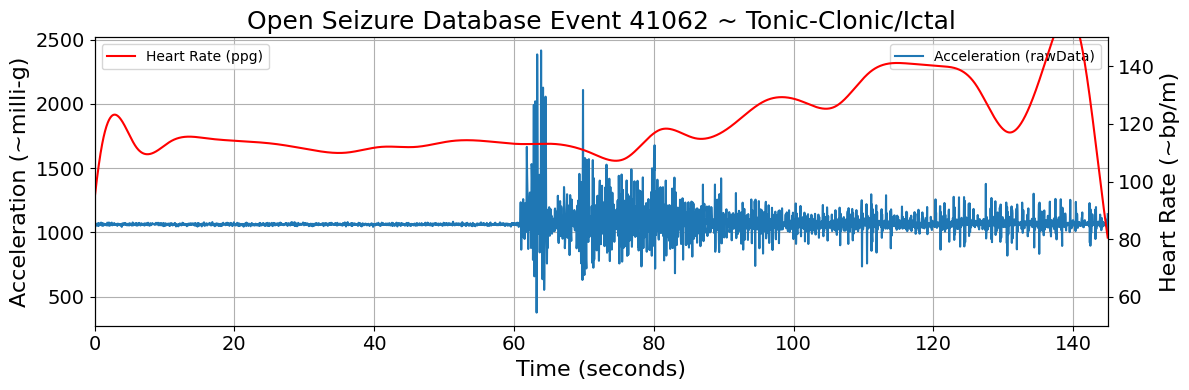

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
import os
import warnings

# Suppress specific warnings
warnings.filterwarnings("ignore", message=".*set_ticklabels.*")

# Reading data from Google Drive
sample_dataset_path = '../Data/sample_dataset.csv'
df = pd.read_csv(sample_dataset_path)
filtered_df = df[df['subType'] == 'Tonic-Clonic']


# Create 'Events' folder if it doesn't exist
os.makedirs("Events", exist_ok=True)

# Plot each eventId
for event_id, event_data in filtered_df.groupby("eventId"):
    num_rows = event_data.shape[0]
    time_axis = np.arange(num_rows) / 25  # Assuming 25 samples per second
    time_steps = num_rows // 125  # Calculate timesteps
    subType = event_data["subType"].unique
    # Extract unique labels for each timestep (every 125th row)
    labels = event_data["label"].iloc[::125].reset_index(drop=True)
    label_positions = [i * 5 for i in range(len(labels))]  # Position for each label (5 seconds per timestep)

    # Adding static 0 at the start of ax3's x-ticks to ensure alignment
    adjusted_label_positions = label_positions  # Start with static 0 for the first position
    adjusted_labels = [0] + labels.tolist()  # Add static 0 label for the first position

    fig, ax1 = plt.subplots(figsize=(12, 4))

    # Left Y-axis (Acceleration / rawData)
    ax1.plot(time_axis, event_data["rawData"], color="tab:blue", label="Acceleration (rawData)")  
    ax1.set_xlabel("Time (seconds)", fontsize=16)
    ax1.set_ylabel("Acceleration (~milli-g)", color="black", fontsize=16)
    ax1.tick_params(axis='y', labelcolor="black", labelsize=14)
    ax1.tick_params(axis='x', labelsize=14)

    # Right Y-axis (Heart Rate / ppg)
    ax2 = ax1.twinx()
    ax2.plot(time_axis, event_data["ppg"], color="red", label="Heart Rate (ppg)")  
    ax2.set_ylabel("Heart Rate (~bp/m)", fontsize=16)
    ax2.tick_params(axis='y', labelcolor="black", labelsize=14)

    # Set the same xlim for ax1 and ax3
    ax1.set_xlim(0, time_axis[-1])
    ax2.set_ylim(50,150)
    ax1.grid(True)
    ax1.legend()
    ax2.legend()

    # Title with padding
    plt.title(f"Open Seizure Database Event {event_id} ~ Tonic-Clonic/Ictal", fontsize=18)

    # Adjust layout for spacing
    fig.tight_layout()

     # Save the plot as a PNG image in the 'Events' folder
    plt.savefig(f"../Sample_Event_Types/Tonic-Clonic/event_{event_id}.png")

    # Show the plot
    plt.show()



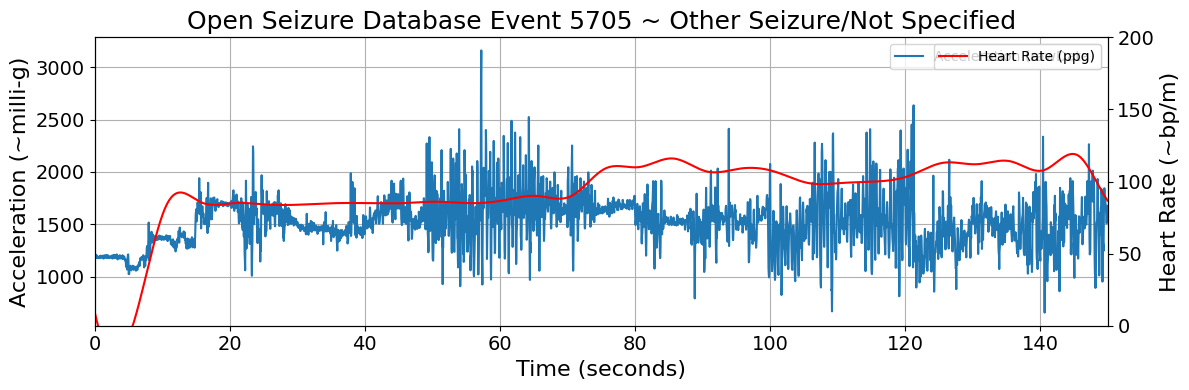

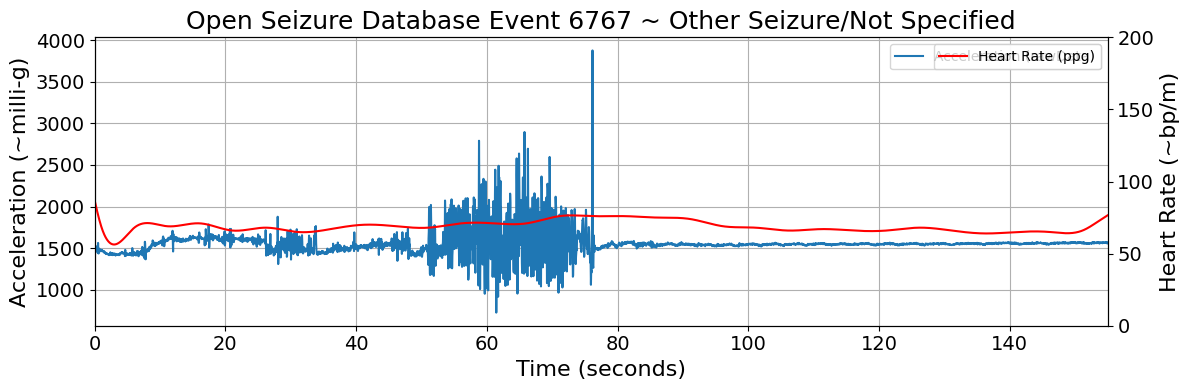

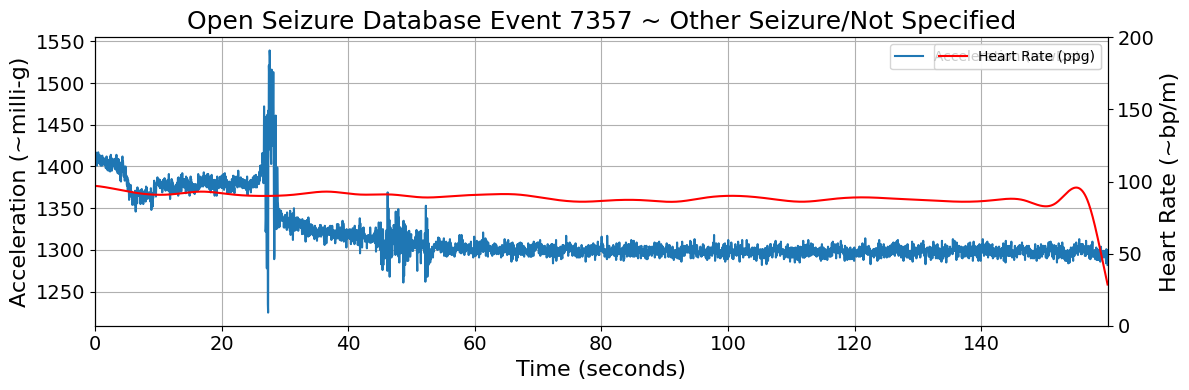

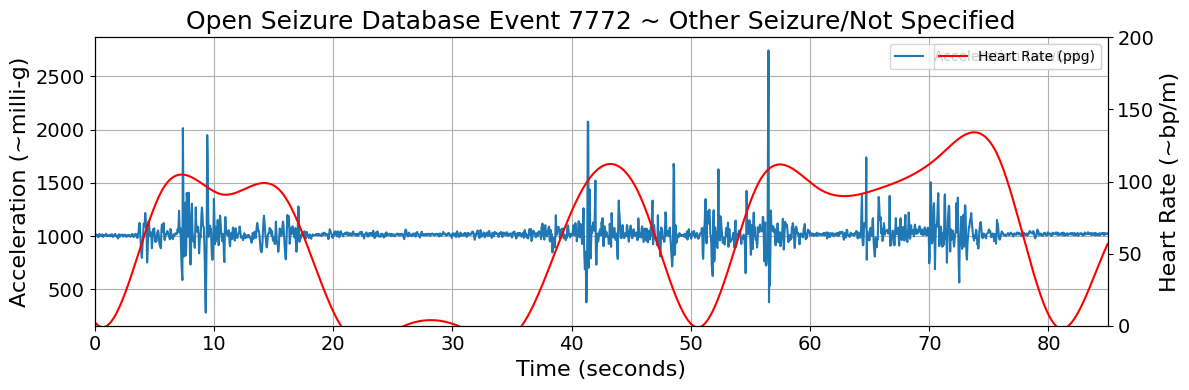

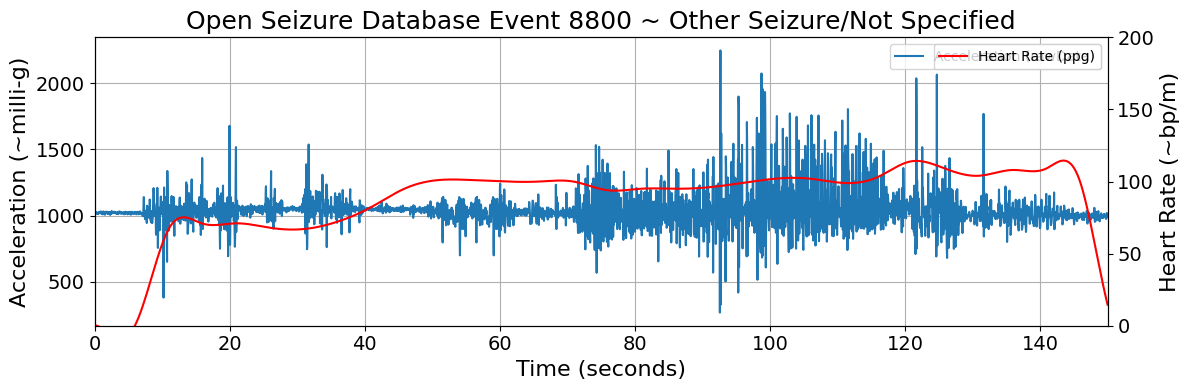

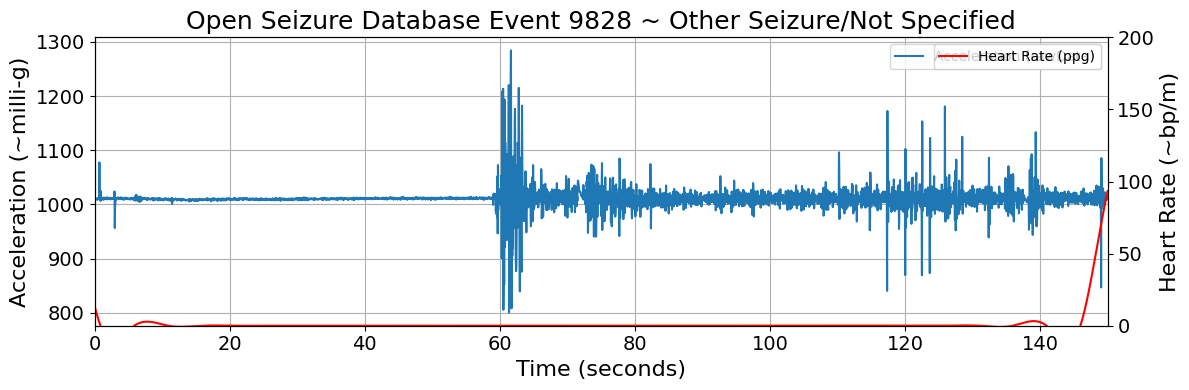

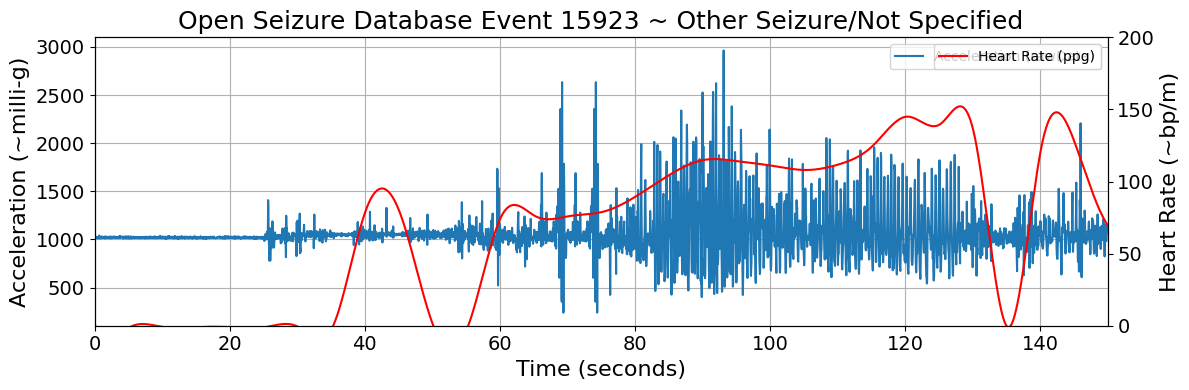

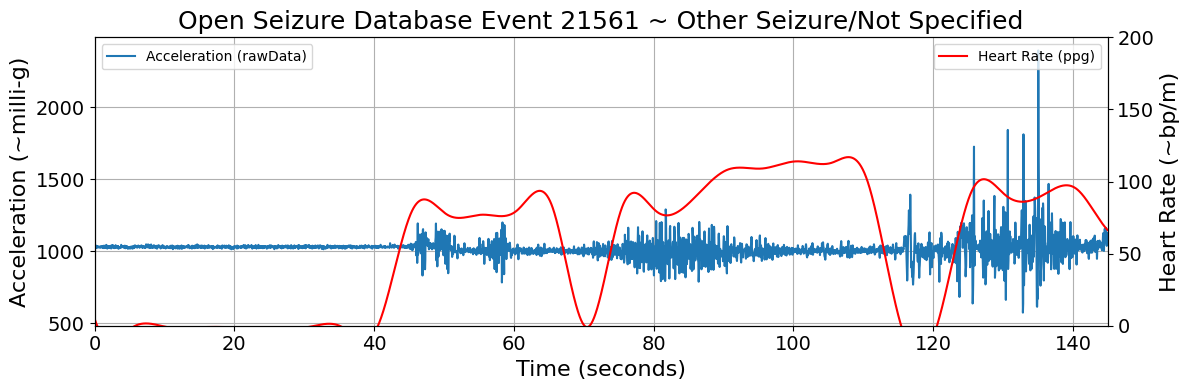

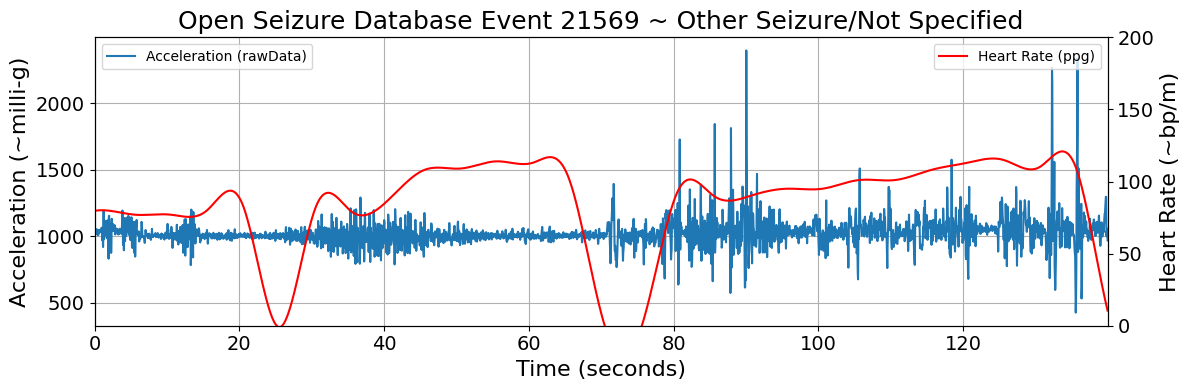

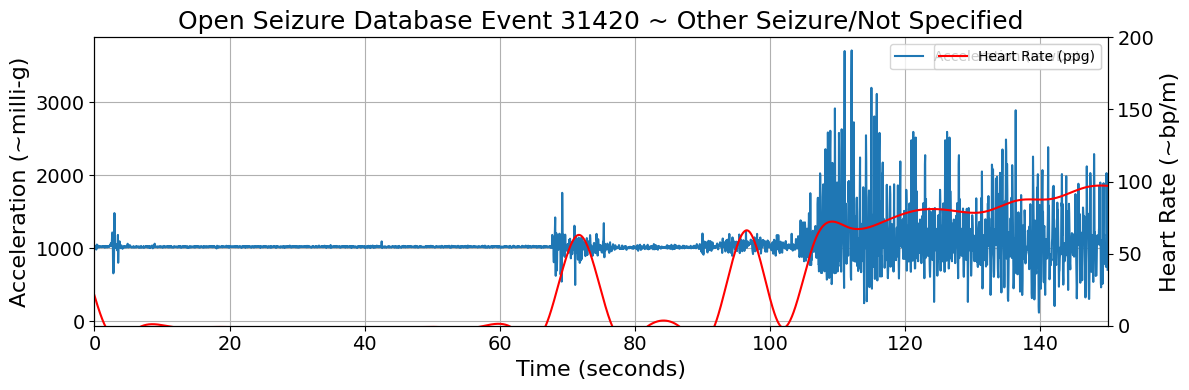

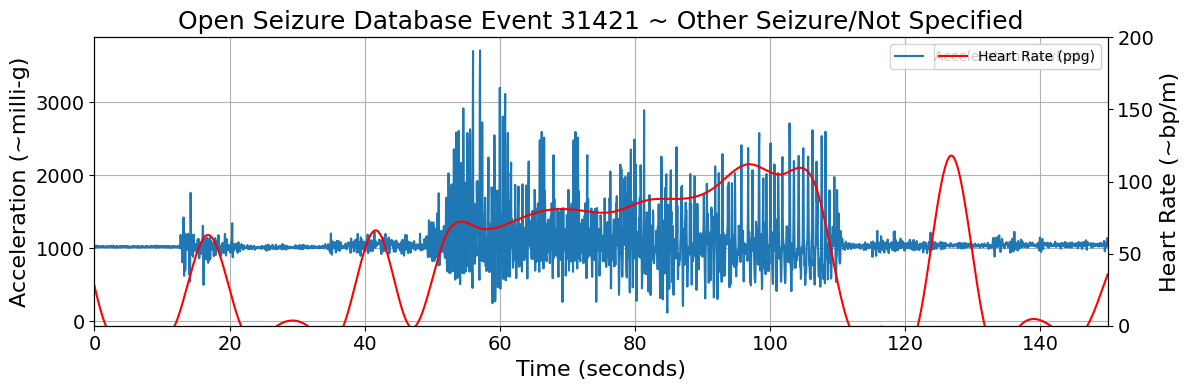

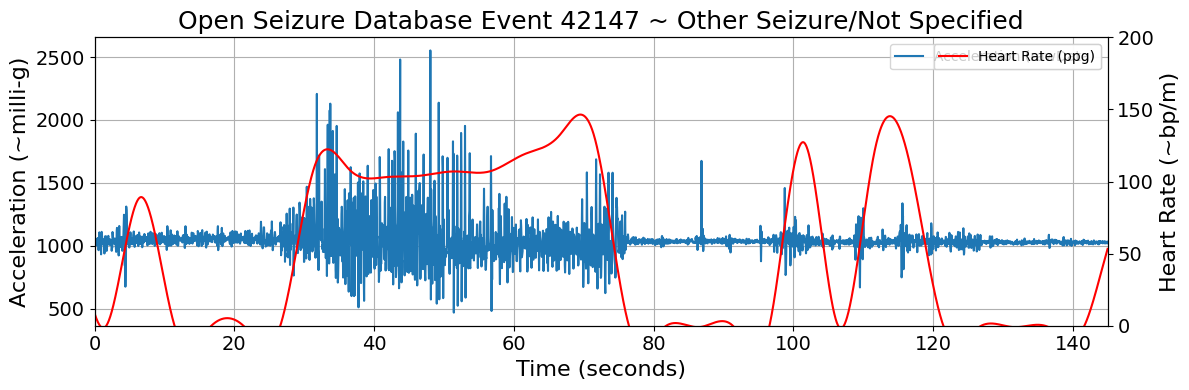

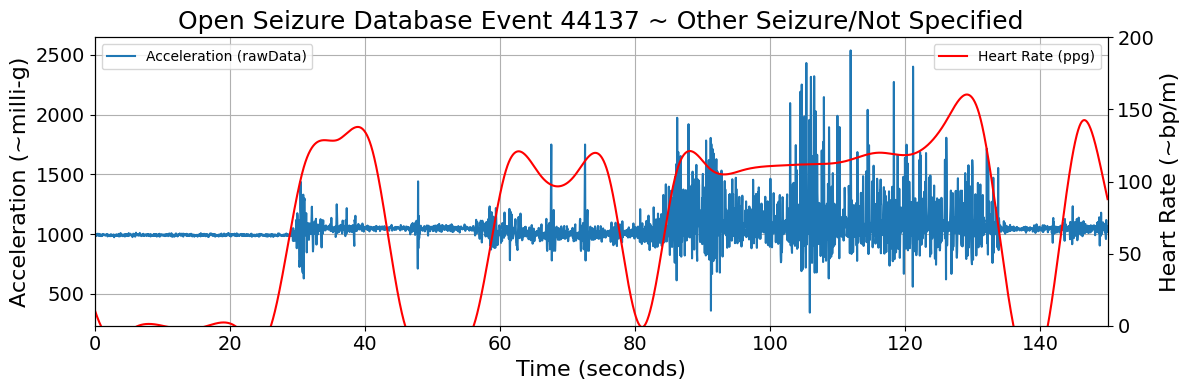

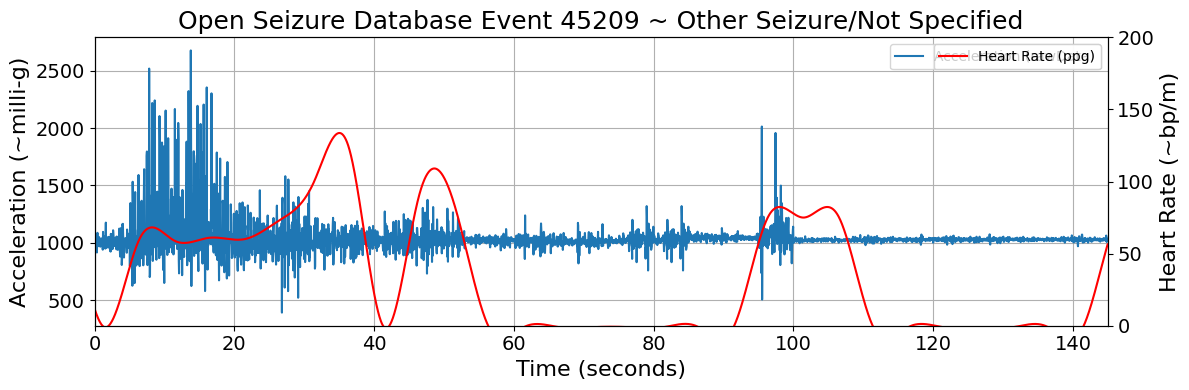

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
import os
import warnings

# Suppress specific warnings
warnings.filterwarnings("ignore", message=".*set_ticklabels.*")

# Reading data from Google Drive
sample_dataset_path = '../Data/sample_dataset.csv'
df = pd.read_csv(sample_dataset_path)
filtered_df = df[df['subType'] == 'Other']


# Create 'Events' folder if it doesn't exist
os.makedirs("Events", exist_ok=True)

# Plot each eventId
for event_id, event_data in filtered_df.groupby("eventId"):
    num_rows = event_data.shape[0]
    time_axis = np.arange(num_rows) / 25  # Assuming 25 samples per second
    time_steps = num_rows // 125  # Calculate timesteps
    subType = event_data["subType"].unique
    # Extract unique labels for each timestep (every 125th row)
    labels = event_data["label"].iloc[::125].reset_index(drop=True)
    label_positions = [i * 5 for i in range(len(labels))]  # Position for each label (5 seconds per timestep)

    # Adding static 0 at the start of ax3's x-ticks to ensure alignment
    adjusted_label_positions = label_positions  # Start with static 0 for the first position
    adjusted_labels = [0] + labels.tolist()  # Add static 0 label for the first position

    fig, ax1 = plt.subplots(figsize=(12, 4))

    # Left Y-axis (Acceleration / rawData)
    ax1.plot(time_axis, event_data["rawData"], color="tab:blue", label="Acceleration (rawData)")  
    ax1.set_xlabel("Time (seconds)", fontsize=16)
    ax1.set_ylabel("Acceleration (~milli-g)", color="black", fontsize=16)
    ax1.tick_params(axis='y', labelcolor="black", labelsize=14)
    ax1.tick_params(axis='x', labelsize=14)

    # Right Y-axis (Heart Rate / ppg)
    ax2 = ax1.twinx()
    ax2.plot(time_axis, event_data["ppg"], color="red", label="Heart Rate (ppg)")  
    ax2.set_ylabel("Heart Rate (~bp/m)", fontsize=16)
    ax2.tick_params(axis='y', labelcolor="black", labelsize=14)

    # Set the same xlim for ax1 and ax3
    ax1.set_xlim(0, time_axis[-1])
    ax2.set_ylim(0,200)
    ax1.grid(True)
    ax1.legend()
    ax2.legend()

    # Title with padding
    plt.title(f"Open Seizure Database Event {event_id} ~ Other Seizure/Not Specified", fontsize=18)

    # Adjust layout for spacing
    fig.tight_layout()

     # Save the plot as a PNG image in the 'Events' folder
    plt.savefig(f"../Sample_Event_Types/Other_Seizures/event_{event_id}.png")

    # Show the plot
    plt.show()

